# XGBoost Regressor  GK Volatility Prediction

**Task**: Predict next-hour Garman-Klass Volatility (`target_reg`)  
**Models**: XGBoost from scratch (Gradient Boosting + XGBoost tricks) and `xgboost` library  
**What is XGBoost?**: An optimised Gradient Boosting framework that adds:
- **L1 + L2 regularisation** on tree leaf weights (prevents overfitting)
- **Second-order gradients** (Newton boosting) for faster, more accurate updates
- **Column subsampling** per tree and per split (like Random Forest)
- **Shrinkage** (learning rate) to slow down learning for better generalisation

**Scratch implementation** replicates core XGBoost logic:  
$$\text{Gain} = \frac{1}{2}\left[\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right] - \gamma$$

Where $G$ = sum of first-order gradients, $H$ = sum of second-order gradients (hessians), $\lambda$ = L2 reg, $\gamma$ = min split gain

---
## 1. Setup & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, os, warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, auc,
)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# File paths
BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), '..'))
TRAIN_FILE    = os.path.join(BASE_DIR, 'data', 'final_training_data_regression_train.csv')
TEST_FILE     = os.path.join(BASE_DIR, 'data', 'final_training_data_regression_test.csv')
FEATURES_FILE = os.path.join(BASE_DIR, 'data', 'selected_features_regression.json')
SCALER_FILE   = os.path.join(BASE_DIR, 'models', 'scaler_regression.pkl')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
RESULTS_DIR   = os.path.join(BASE_DIR, 'results')
PLOTS_DIR     = os.path.join(BASE_DIR, 'plots')
RESULTS_CSV   = os.path.join(RESULTS_DIR, 'regression_results.csv')

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,   exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)

def compute_metrics(model_name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-10)))) * 100
    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    print(f"  MSE     : {mse:.8f}")
    print(f"  RMSE    : {rmse:.8f}")
    print(f"  MAE     : {mae:.8f}")
    print(f"  R²      : {r2:.4f}")
    print(f"  MAPE(%) : {mape:.4f}")
    print(f"{'='*55}")
    return {'model': model_name, 'mse': round(mse,8), 'rmse': round(rmse,8),
            'mae': round(mae,8), 'r2': round(r2,4), 'mape': round(mape,4)}

def save_results(metrics_dict):
    row = pd.DataFrame([metrics_dict])
    if os.path.exists(RESULTS_CSV):
        existing = pd.read_csv(RESULTS_CSV)
        existing = existing[existing['model'] != metrics_dict['model']]
        row = pd.concat([existing, row], ignore_index=True)
    row.to_csv(RESULTS_CSV, index=False)
    print(f"Results saved → {RESULTS_CSV}")

print('Libraries loaded')
print(f'BASE_DIR    : {BASE_DIR}')
print(f'RESULTS_DIR : {RESULTS_DIR}')
print(f'PLOTS_DIR   : {PLOTS_DIR}')

Libraries loaded
BASE_DIR    : d:\ML\crypto project\cryptoflow
RESULTS_DIR : d:\ML\crypto project\cryptoflow\results
PLOTS_DIR   : d:\ML\crypto project\cryptoflow\plots


In [2]:
train = pd.read_csv(TRAIN_FILE, parse_dates=['open time'])
test  = pd.read_csv(TEST_FILE,  parse_dates=['open time'])

with open(FEATURES_FILE) as f:
    feature_cols = json.load(f)

if os.path.exists(SCALER_FILE):
    with open(SCALER_FILE, 'rb') as f:
        scaler = pickle.load(f)
    X_train = scaler.transform(train[feature_cols].values)
    X_test  = scaler.transform(test[feature_cols].values)
else:
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(train[feature_cols].values)
    X_test  = scaler.transform(test[feature_cols].values)

y_train = train['target_reg'].values
y_test  = test['target_reg'].values

val_cut  = int(len(X_train) * 0.85)
X_tr, X_val = X_train[:val_cut], X_train[val_cut:]
y_tr, y_val = y_train[:val_cut], y_train[val_cut:]

print(f'Train: {len(train):,} rows | Test: {len(test):,} rows')
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Features ({len(feature_cols)}): {feature_cols}')

Train: 60,260 rows | Test: 10,635 rows
X_train: (60260, 10) | X_test: (10635, 10)
Features (10): ['hl_range_pct', 'gk_avg_6h', 'gk_lag_6h', 'hour_cos', 'gk_avg_3h', 'gk_lag_1h', 'trade_intensity', 'log_return_3h', 'log_return_6h', 'atr_lag_3h']


---
## 2. Data Analysis

=== Target Variable Statistics ===
              Train          Test
count  60260.000000  10635.000000
mean       0.006115      0.003886
std        0.005756      0.003113
min        0.000000      0.000229
25%        0.002852      0.001998
50%        0.004590      0.003076
75%        0.007497      0.004795
max        0.213448      0.085401


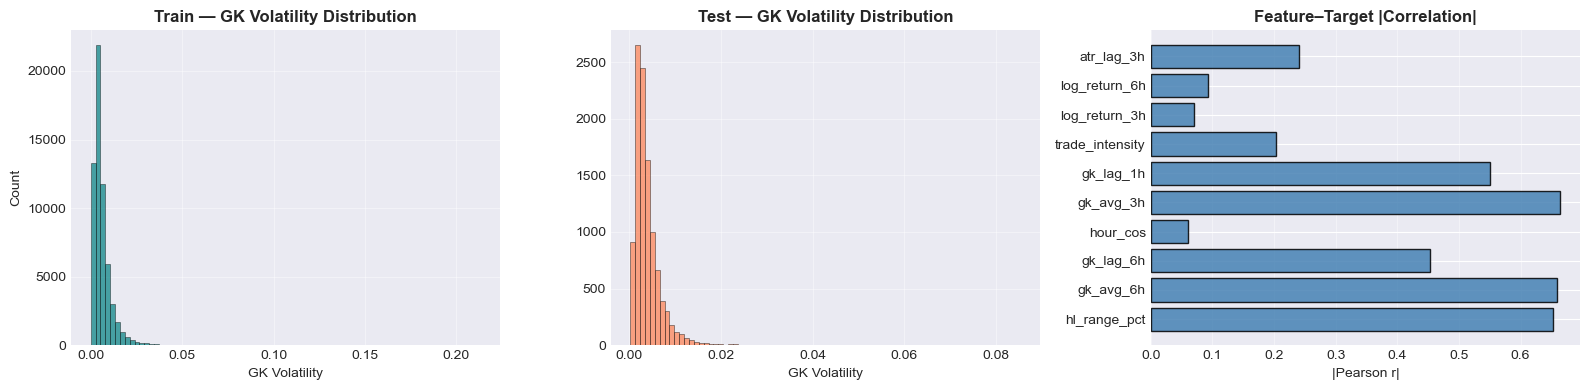

In [3]:
print('=== Target Variable Statistics ===')
print(pd.DataFrame({'Train': pd.Series(y_train).describe(),
                    'Test' : pd.Series(y_test).describe()}).round(8))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y_train, bins=80, alpha=0.7, color='teal', edgecolor='black', linewidth=0.4)
axes[0].set_title('Train — GK Volatility Distribution', fontweight='bold')
axes[0].set_xlabel('GK Volatility'); axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.4)

axes[1].hist(y_test, bins=80, alpha=0.7, color='coral', edgecolor='black', linewidth=0.4)
axes[1].set_title('Test — GK Volatility Distribution', fontweight='bold')
axes[1].set_xlabel('GK Volatility'); axes[1].grid(alpha=0.4)

corrs = [abs(np.corrcoef(X_train[:, i], y_train)[0, 1]) for i in range(X_train.shape[1])]
axes[2].barh(feature_cols, corrs, color='steelblue', alpha=0.85, edgecolor='black')
axes[2].set_title('Feature–Target |Correlation|', fontweight='bold')
axes[2].set_xlabel('|Pearson r|'); axes[2].grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'xgb_data_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 3. XGBoost from Scratch

**Core XGBoost algorithm (MSE loss):**
1. Initialise $F_0(x) = \bar{y}$
2. For each tree $m$:
   - Compute **first-order gradients**: $g_i = F_{m-1}(x_i) - y_i$  
   - Compute **second-order gradients (hessians)**: $h_i = 1$ (for MSE)
   - Find optimal splits using XGBoost Gain formula
   - Compute **optimal leaf weights**: $w^* = -G / (H + \lambda)$
   - Update: $F_m(x) = F_{m-1}(x) + \eta \cdot T_m(x)$
3. Regularisation: $\lambda$ (L2 on leaf weights), $\gamma$ (min gain to split)

**Key differences from plain Gradient Boosting:**
- Uses **second-order (Newton) gradients** → more accurate splits
- **L1/L2 regularisation** directly on leaf weights
- **Column subsampling** per tree (`colsample_bytree`)

In [4]:
class XGBTreeNode:
    """Single node in an XGBoost decision tree."""
    def __init__(self):
        self.is_leaf      = False
        self.leaf_weight  = 0.0
        self.feature_idx  = None
        self.threshold    = None
        self.left         = None
        self.right        = None


class XGBTree:
    """A single regression tree built using XGBoost split criterion."""

    def __init__(self, max_depth=3, min_child_weight=1,
                 reg_lambda=1.0, reg_gamma=0.0, colsample=1.0):
        self.max_depth       = max_depth
        self.min_child_weight = min_child_weight
        self.reg_lambda      = reg_lambda
        self.reg_gamma       = reg_gamma
        self.colsample       = colsample
        self.root            = None
        self.n_features      = None

    def _gain(self, G, H):
        """XGBoost leaf score = -G^2 / (2*(H + lambda))."""
        return (G ** 2) / (2.0 * (H + self.reg_lambda))

    def _split_gain(self, GL, HL, GR, HR):
        """Net gain of a split vs no-split."""
        return self._gain(GL, HL) + self._gain(GR, HR)                - self._gain(GL + GR, HL + HR) - self.reg_gamma

    def _leaf_weight(self, G, H):
        """Optimal leaf weight = -G / (H + lambda)."""
        return -G / (H + self.reg_lambda)

    def _best_split(self, X, grads, hessians, feature_indices):
        """Find the best (feature, threshold) pair over feature_indices."""
        best_gain = -np.inf
        best_feat = best_thresh = None
        G_tot = grads.sum()
        H_tot = hessians.sum()

        for feat in feature_indices:
            values = X[:, feat]
            sorted_idx = np.argsort(values)
            sv = values[sorted_idx]
            sg = grads[sorted_idx]
            sh = hessians[sorted_idx]

            GL, HL = 0.0, 0.0
            for j in range(len(sv) - 1):
                GL += sg[j]; HL += sh[j]
                GR = G_tot - GL; HR = H_tot - HL
                # skip if child too small
                if HL < self.min_child_weight or HR < self.min_child_weight:
                    continue
                # skip duplicate thresholds
                if sv[j] == sv[j + 1]:
                    continue
                gain = self._split_gain(GL, HL, GR, HR)
                if gain > best_gain:
                    best_gain  = gain
                    best_feat  = feat
                    best_thresh = (sv[j] + sv[j + 1]) / 2.0

        return best_feat, best_thresh, best_gain

    def _build(self, X, grads, hessians, depth):
        node = XGBTreeNode()
        G, H = grads.sum(), hessians.sum()

        if depth >= self.max_depth or len(grads) < 2:
            node.is_leaf     = True
            node.leaf_weight = self._leaf_weight(G, H)
            return node

        # random column subsampling
        n_feats = max(1, int(self.n_features * self.colsample))
        feat_idx = np.random.choice(self.n_features, n_feats, replace=False)

        feat, thresh, gain = self._best_split(X, grads, hessians, feat_idx)

        if feat is None or gain <= 0:
            node.is_leaf     = True
            node.leaf_weight = self._leaf_weight(G, H)
            return node

        mask = X[:, feat] <= thresh
        node.feature_idx = feat
        node.threshold   = thresh
        node.left  = self._build(X[mask],  grads[mask],  hessians[mask],  depth + 1)
        node.right = self._build(X[~mask], grads[~mask], hessians[~mask], depth + 1)
        return node

    def fit(self, X, grads, hessians):
        self.n_features = X.shape[1]
        self.root = self._build(X, grads, hessians, depth=0)
        return self

    def _predict_one(self, x, node):
        if node.is_leaf:
            return node.leaf_weight
        if x[node.feature_idx] <= node.threshold:
            return self._predict_one(x, node.left)
        return self._predict_one(x, node.right)

    def predict(self, X):
        return np.array([self._predict_one(row, self.root) for row in X])


class XGBoostScratch:
    """
    XGBoost Regressor from scratch.
    Uses Newton boosting (second-order gradients) with L1/L2 regularisation.
    """
    def __init__(self, n_estimators=100, learning_rate=0.1,
                 max_depth=3, min_child_weight=1,
                 reg_lambda=1.0, reg_gamma=0.0,
                 subsample=0.8, colsample_bytree=0.8,
                 verbose=True):
        self.n_estimators     = n_estimators
        self.learning_rate    = learning_rate
        self.max_depth        = max_depth
        self.min_child_weight = min_child_weight
        self.reg_lambda       = reg_lambda
        self.reg_gamma        = reg_gamma
        self.subsample        = subsample
        self.colsample        = colsample_bytree
        self.verbose          = verbose
        self.trees            = []
        self.F0               = 0.0
        self.train_losses     = []
        self.val_losses       = []

    def _grad_hess_mse(self, y_true, y_pred):
        """MSE loss: grad = pred - true, hess = 1 (constant)."""
        g = y_pred - y_true
        h = np.ones_like(g)
        return g, h

    def fit(self, X, y, X_val=None, y_val=None):
        n = len(y)
        self.F0 = np.mean(y)
        F = np.full(n, self.F0)

        for m in range(self.n_estimators):
            # row subsampling
            idx = np.random.choice(n, int(n * self.subsample), replace=False)
            Xs, ys, Fs = X[idx], y[idx], F[idx]

            g, h = self._grad_hess_mse(ys, Fs)

            tree = XGBTree(
                max_depth=self.max_depth,
                min_child_weight=self.min_child_weight,
                reg_lambda=self.reg_lambda,
                reg_gamma=self.reg_gamma,
                colsample=self.colsample,
            )
            tree.fit(Xs, g, h)
            self.trees.append(tree)

            # update full training predictions
            F += self.learning_rate * tree.predict(X)

            train_mse = float(np.mean((F - y) ** 2))
            self.train_losses.append(train_mse)

            if X_val is not None:
                val_pred = self.predict(X_val)
                self.val_losses.append(float(np.mean((val_pred - y_val) ** 2)))

            if self.verbose and (m + 1) % 20 == 0:
                msg = f'  Iter {m+1:4d}/{self.n_estimators}  Train MSE: {train_mse:.8f}'
                if X_val is not None:
                    msg += f' | Val MSE: {self.val_losses[-1]:.8f}'
                print(msg)
        return self

    def predict(self, X):
        pred = np.full(len(X), self.F0)
        for tree in self.trees:
            pred += self.learning_rate * tree.predict(X)
        return pred

    def feature_importance(self, feature_names=None):
        """Count-based feature importance (split frequency)."""
        counts = {}
        def _traverse(node):
            if node.is_leaf: return
            feat = node.feature_idx
            counts[feat] = counts.get(feat, 0) + 1
            _traverse(node.left); _traverse(node.right)
        for tree in self.trees:
            _traverse(tree.root)
        if feature_names:
            return pd.Series({feature_names[k]: v for k, v in counts.items()}).sort_values(ascending=False)
        return pd.Series(counts).sort_values(ascending=False)

print('XGBoostScratch defined')

XGBoostScratch defined


---
## 4. Hyperparameter Tuning (learning rate & n_estimators)

In [5]:
# We use n_estimators=50 for the grid search, then train the best config fully.

print('=== Learning Rate Grid Search (Scratch XGBoost) ===')
lr_grid   = [0.05, 0.10, 0.20]
best_lr_s = None
best_val_s = np.inf

for lr in lr_grid:
    xgb_tmp = XGBoostScratch(
        n_estimators=50, learning_rate=lr,
        max_depth=3, subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, reg_gamma=0.0, verbose=False
    )
    xgb_tmp.fit(X_tr, y_tr, X_val=X_val, y_val=y_val)
    val_r2 = r2_score(y_val, xgb_tmp.predict(X_val))
    print(f'  lr={lr:.2f}  Val R²={val_r2:.4f}')
    if xgb_tmp.val_losses[-1] < best_val_s:
        best_val_s = xgb_tmp.val_losses[-1]
        best_lr_s  = lr

print(f'\nBest learning rate (Scratch): {best_lr_s}')

=== Learning Rate Grid Search (Scratch XGBoost) ===
  lr=0.05  Val R²=0.3511
  lr=0.10  Val R²=0.3632
  lr=0.20  Val R²=0.3611

Best learning rate (Scratch): 0.1


---
## 5. Train XGBoost from Scratch

In [6]:
print(f'=== Training Scratch XGBoost (lr={best_lr_s}, n=100) ===')
xgb_scratch = XGBoostScratch(
    n_estimators=100,
    learning_rate=best_lr_s,
    max_depth=3,
    min_child_weight=1,
    reg_lambda=1.0,
    reg_gamma=0.0,
    subsample=0.8,
    colsample_bytree=0.8,
    verbose=True,
)
xgb_scratch.fit(X_tr, y_tr, X_val=X_val, y_val=y_val)

y_pred_train_scratch = xgb_scratch.predict(X_train)
y_pred_test_scratch  = xgb_scratch.predict(X_test)

print(f'\nScratch  Train R²: {r2_score(y_train, y_pred_train_scratch):.4f}')
print(f'Scratch  Test  R²: {r2_score(y_test,  y_pred_test_scratch):.4f}')

=== Training Scratch XGBoost (lr=0.1, n=100) ===
  Iter   20/100  Train MSE: 0.00001784 | Val MSE: 0.00000818
  Iter   40/100  Train MSE: 0.00001650 | Val MSE: 0.00000789
  Iter   60/100  Train MSE: 0.00001596 | Val MSE: 0.00000782
  Iter   80/100  Train MSE: 0.00001563 | Val MSE: 0.00000781
  Iter  100/100  Train MSE: 0.00001537 | Val MSE: 0.00000778

Scratch  Train R²: 0.5706
Scratch  Test  R²: 0.3712


---
## 6. XGBoost (xgboost library)

In [7]:
print('=== Training xgboost library (n=200) ===')
xgb_sk = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    gamma=0.0,
    min_child_weight=1,
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
xgb_sk.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

y_pred_train_sk = xgb_sk.predict(X_train)
y_pred_test_sk  = xgb_sk.predict(X_test)

print(f'sklearn  Train R²: {r2_score(y_train, y_pred_train_sk):.4f}')
print(f'sklearn  Test  R²: {r2_score(y_test,  y_pred_test_sk):.4f}')
print('\nxgboost library uses 200 estimators + C/C++ optimisation → faster & higher R²')

print('\nScratch vs sklearn R² comparison:')
print(f'  Scratch : {r2_score(y_test, y_pred_test_scratch):.4f}')
print(f'  sklearn : {r2_score(y_test, y_pred_test_sk):.4f}')

=== Training xgboost library (n=200) ===
sklearn  Train R²: 0.5444
sklearn  Test  R²: 0.3614

xgboost library uses 200 estimators + C/C++ optimisation → faster & higher R²

Scratch vs sklearn R² comparison:
  Scratch : 0.3712
  sklearn : 0.3614


---
## 7. Loss & Regression Metrics (MSE / RMSE / MAE / R² / MAPE)

In [8]:
models_pred = {
    f'XGB Scratch (lr={best_lr_s})' : (y_pred_train_scratch, y_pred_test_scratch),
    'XGB sklearn (lr=0.05)'         : (y_pred_train_sk,      y_pred_test_sk),
}

all_metrics = {}
for name, (y_tr_p, y_te_p) in models_pred.items():
    all_metrics[name] = compute_metrics(name, y_test, y_te_p)

for name, m in all_metrics.items():
    save_results(m)


  XGB Scratch (lr=0.1)
  MSE     : 0.00000609
  RMSE    : 0.00246839
  MAE     : 0.00163721
  R²      : 0.3712
  MAPE(%) : 58.1143

  XGB sklearn (lr=0.05)
  MSE     : 0.00000619
  RMSE    : 0.00248766
  MAE     : 0.00164895
  R²      : 0.3614
  MAPE(%) : 58.3541
Results saved → d:\ML\crypto project\cryptoflow\results\regression_results.csv
Results saved → d:\ML\crypto project\cryptoflow\results\regression_results.csv


---
## 8. R² Score

=== R² Score Summary ===
XGB Scratch (lr=0.1)            Train R²: 0.570592  |  Test R²: 0.371233
XGB sklearn (lr=0.05)           Train R²: 0.544434  |  Test R²: 0.361376


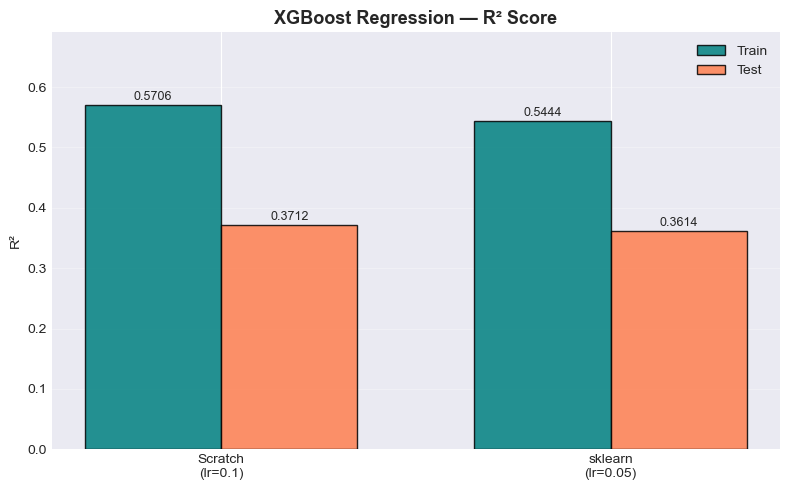

In [9]:
print('=== R² Score Summary ===')
for name, (y_tr_p, y_te_p) in models_pred.items():
    print(f'{name:30s}  Train R²: {r2_score(y_train, y_tr_p):.6f}  |  Test R²: {r2_score(y_test, y_te_p):.6f}')

short = [f'Scratch\n(lr={best_lr_s})', 'sklearn\n(lr=0.05)']
r2_train_vals = [r2_score(y_train, v[0]) for v in models_pred.values()]
r2_test_vals  = [r2_score(y_test,  v[1]) for v in models_pred.values()]

x = np.arange(2); w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, r2_train_vals, w, label='Train', color='teal',  alpha=0.85, edgecolor='black')
b2 = ax.bar(x + w/2, r2_test_vals,  w, label='Test',  color='coral', alpha=0.85, edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(short)
ax.set_ylabel('R²'); ax.set_title('XGBoost Regression — R² Score', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar, v in [(b, vv) for bars, vs in [(b1,r2_train_vals),(b2,r2_test_vals)] for b,vv in zip(bars,vs)]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, max(r2_train_vals + r2_test_vals) + 0.12)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'xgb_r2.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Loss Curves (Boosting Iterations)

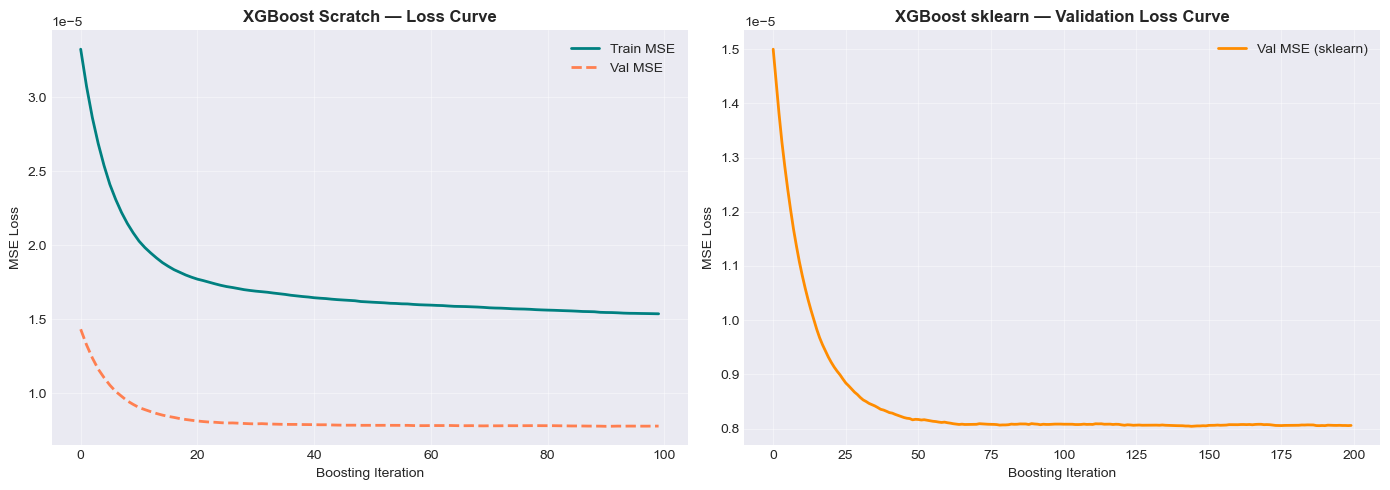

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scratch loss curves
axes[0].plot(xgb_scratch.train_losses, color='teal',  lw=2,   label='Train MSE')
if xgb_scratch.val_losses:
    axes[0].plot(xgb_scratch.val_losses, color='coral', lw=2, ls='--', label='Val MSE')
axes[0].set_xlabel('Boosting Iteration'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('XGBoost Scratch — Loss Curve', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.4)

# sklearn eval results
evals = xgb_sk.evals_result()
if evals:
    val_rmse = evals['validation_0']['rmse']
    axes[1].plot([v**2 for v in val_rmse], color='darkorange', lw=2, label='Val MSE (sklearn)')
    axes[1].set_xlabel('Boosting Iteration'); axes[1].set_ylabel('MSE Loss')
    axes[1].set_title('XGBoost sklearn — Validation Loss Curve', fontweight='bold')
    axes[1].legend(); axes[1].grid(alpha=0.4)
else:
    axes[1].plot(xgb_scratch.train_losses, color='teal', lw=2, label='Train MSE (Scratch)')
    axes[1].semilogy(xgb_scratch.train_losses, color='darkorange', lw=2, label='Train (log scale)')
    axes[1].set_title('Loss Curve — Log Scale', fontweight='bold')
    axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('MSE')
    axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'xgb_loss_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Feature Importance

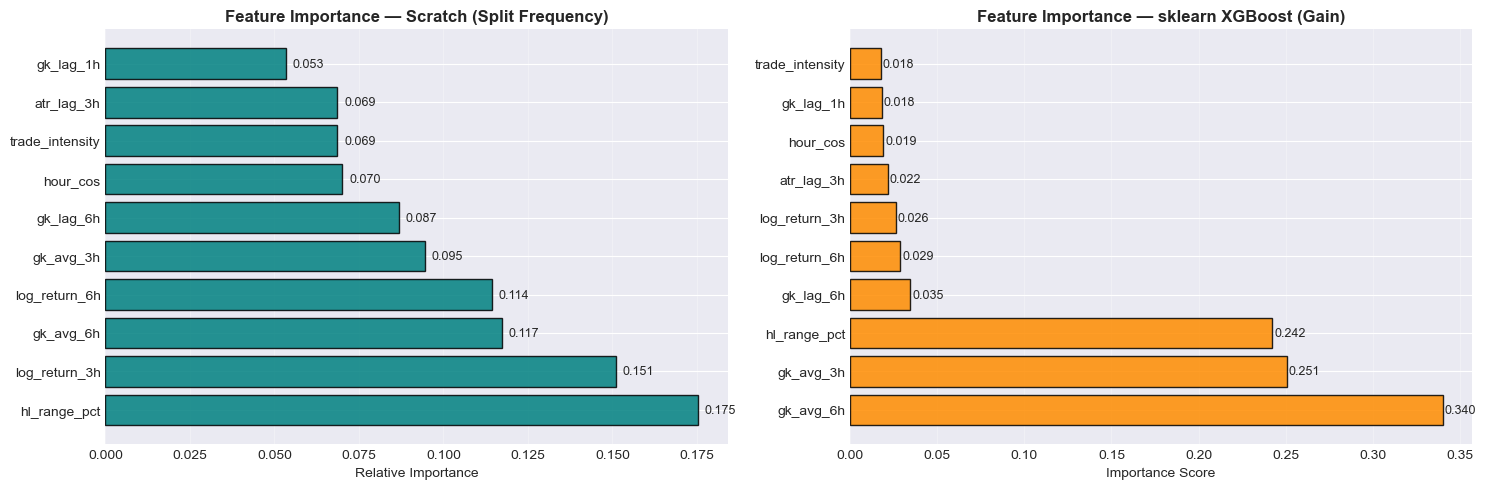


Top 5 features (sklearn):
gk_avg_6h        0.340061
gk_avg_3h        0.250834
hl_range_pct     0.242429
gk_lag_6h        0.034649
log_return_6h    0.028885
dtype: float32


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scratch feature importance
fi_scratch = xgb_scratch.feature_importance(feature_cols)
fi_scratch_norm = fi_scratch / fi_scratch.sum()
colors_s = ['teal' if v >= 0 else 'salmon' for v in fi_scratch_norm.values]
axes[0].barh(fi_scratch_norm.index, fi_scratch_norm.values,
             color='teal', alpha=0.85, edgecolor='black')
axes[0].set_title('Feature Importance — Scratch (Split Frequency)', fontweight='bold')
axes[0].set_xlabel('Relative Importance'); axes[0].grid(axis='x', alpha=0.3)
for i, (feat, val) in enumerate(fi_scratch_norm.items()):
    axes[0].text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)

# sklearn feature importance
fi_sk = pd.Series(xgb_sk.feature_importances_, index=feature_cols).sort_values(ascending=False)
axes[1].barh(fi_sk.index, fi_sk.values, color='darkorange', alpha=0.85, edgecolor='black')
axes[1].set_title('Feature Importance — sklearn XGBoost (Gain)', fontweight='bold')
axes[1].set_xlabel('Importance Score'); axes[1].grid(axis='x', alpha=0.3)
for i, (feat, val) in enumerate(fi_sk.items()):
    axes[1].text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'xgb_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 features (sklearn):')
print(fi_sk.head())

---
## 15. Actual vs Predicted & Residual Analysis

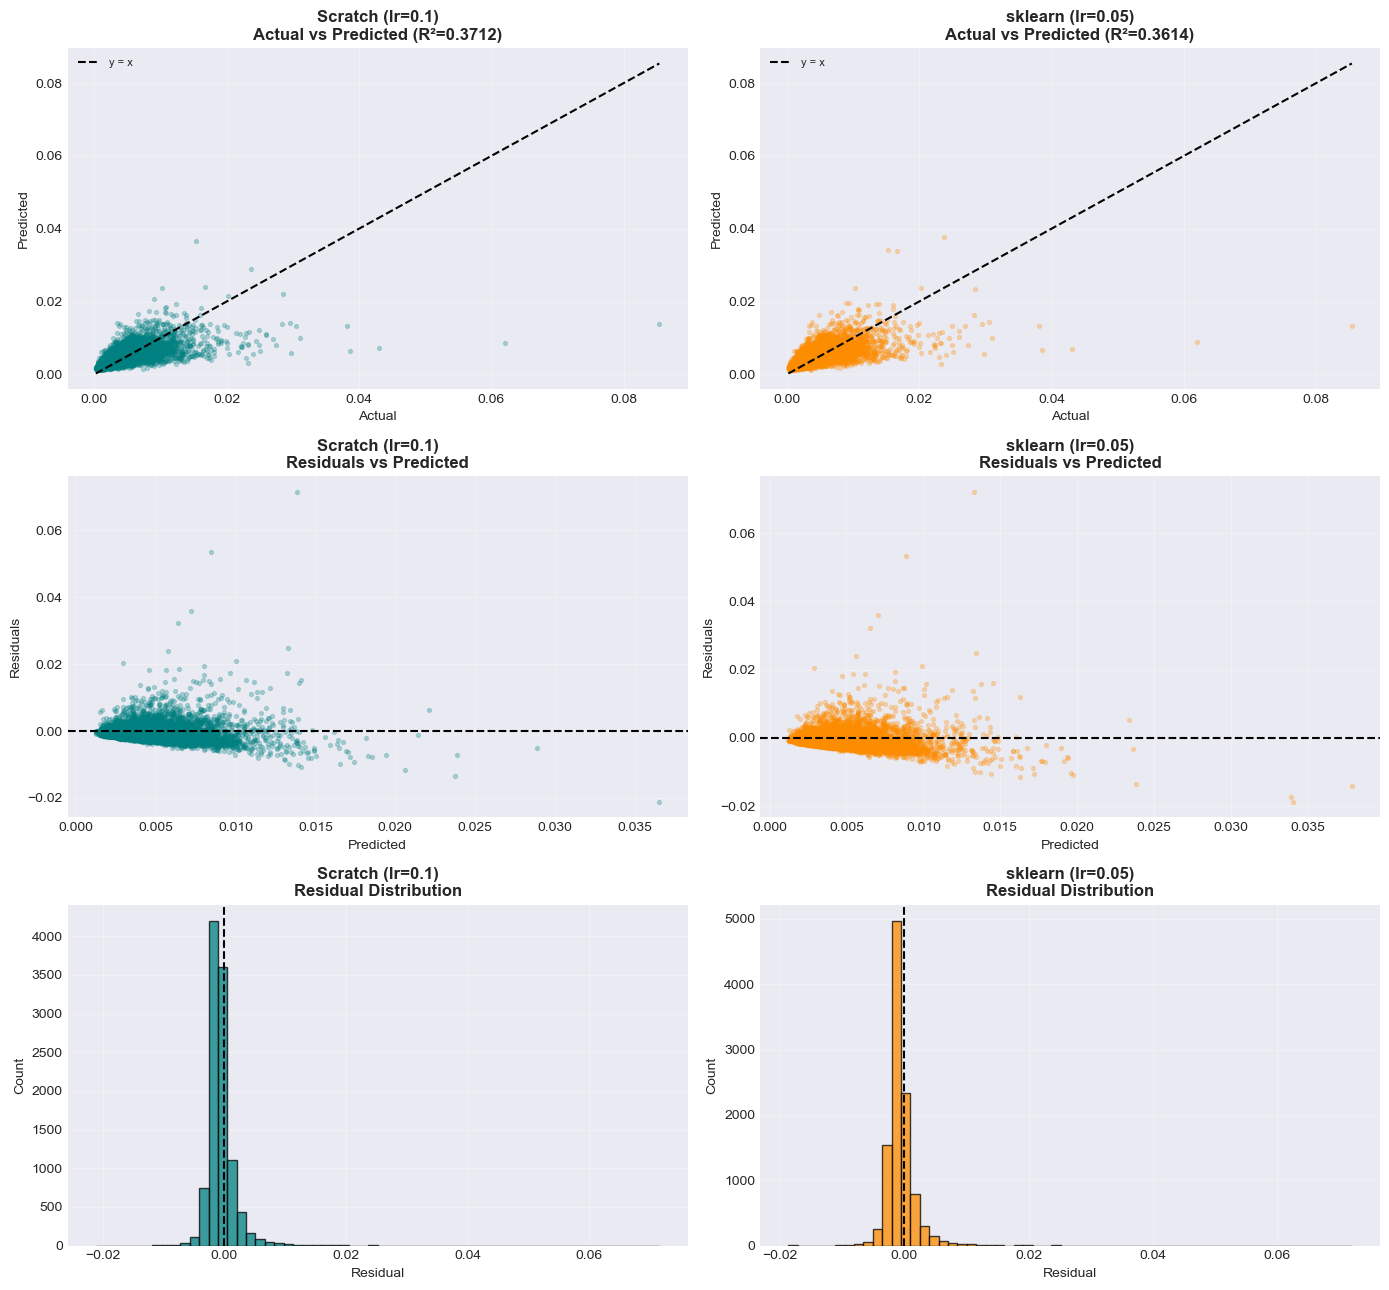

In [12]:
pred_list = [
    (f'Scratch (lr={best_lr_s})', y_pred_test_scratch, 'teal'),
    ('sklearn (lr=0.05)',         y_pred_test_sk,      'darkorange'),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 13))

for col, (title, y_pred, color) in enumerate(pred_list):
    r2 = r2_score(y_test, y_pred)

    # Actual vs Predicted scatter
    axes[0, col].scatter(y_test, y_pred, alpha=0.25, s=8, color=color)
    mn = min(y_test.min(), y_pred.min()); mx = max(y_test.max(), y_pred.max())
    axes[0, col].plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='y = x')
    axes[0, col].set_title(f'{title}\nActual vs Predicted (R²={r2:.4f})', fontweight='bold')
    axes[0, col].set_xlabel('Actual'); axes[0, col].set_ylabel('Predicted')
    axes[0, col].legend(fontsize=8); axes[0, col].grid(alpha=0.3)

    # Residuals vs Predicted
    res = y_test - y_pred
    axes[1, col].scatter(y_pred, res, alpha=0.25, s=8, color=color)
    axes[1, col].axhline(0, color='black', lw=1.5, ls='--')
    axes[1, col].set_title(f'{title}\nResiduals vs Predicted', fontweight='bold')
    axes[1, col].set_xlabel('Predicted'); axes[1, col].set_ylabel('Residuals')
    axes[1, col].grid(alpha=0.3)

    # Residual histogram
    axes[2, col].hist(res, bins=60, color=color, alpha=0.75, edgecolor='black')
    axes[2, col].axvline(0, color='black', lw=1.5, ls='--')
    axes[2, col].set_title(f'{title}\nResidual Distribution', fontweight='bold')
    axes[2, col].set_xlabel('Residual'); axes[2, col].set_ylabel('Count')
    axes[2, col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'xgb_residual_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 16. Time-Series Prediction Plot

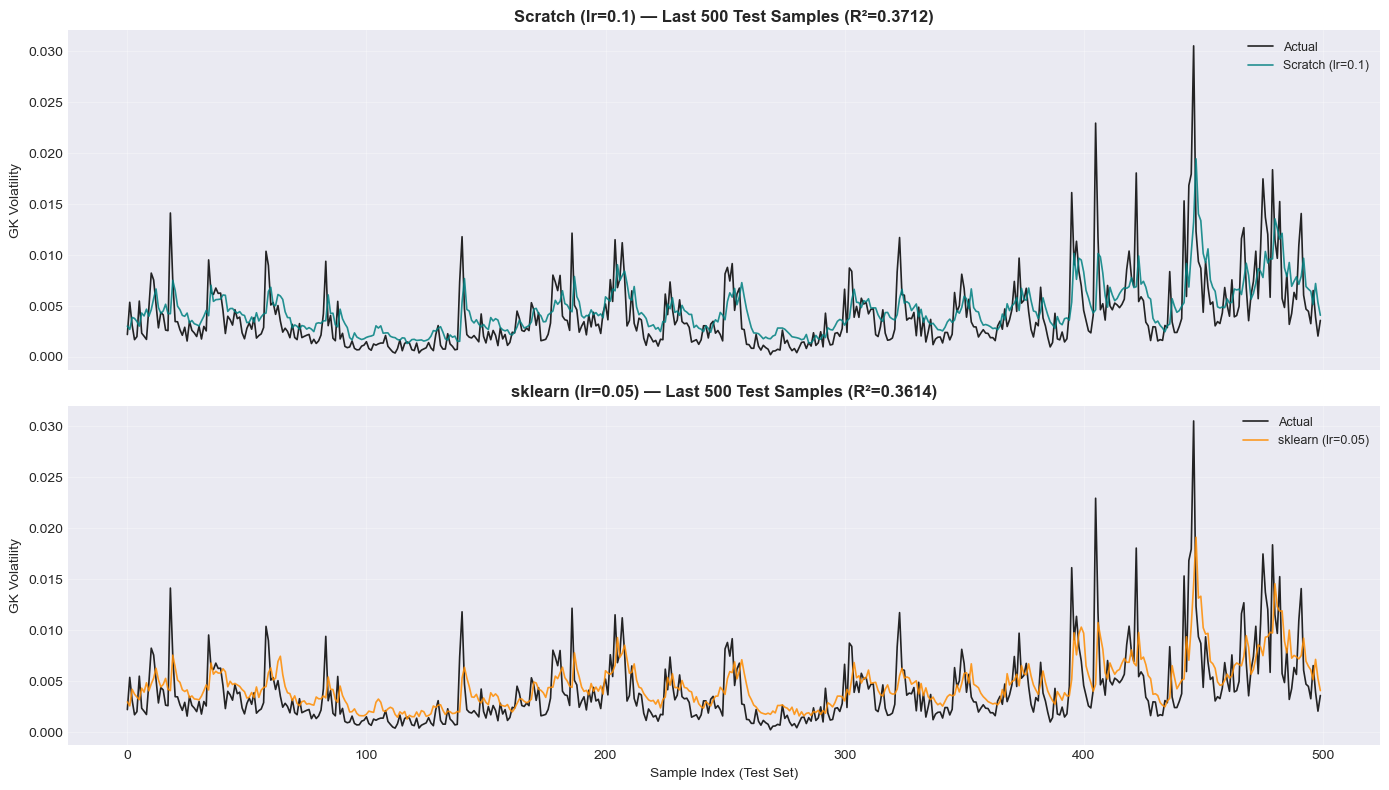

In [13]:
n_plot = 500
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, (title, y_pred, color) in zip(axes, pred_list):
    ax.plot(range(n_plot), y_test[-n_plot:],  color='black', lw=1.2, label='Actual', alpha=0.85)
    ax.plot(range(n_plot), y_pred[-n_plot:],  color=color,   lw=1.2, label=title,   alpha=0.85)
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{title} — Last {n_plot} Test Samples (R²={r2:.4f})', fontweight='bold')
    ax.set_ylabel('GK Volatility'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

axes[-1].set_xlabel('Sample Index (Test Set)')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'xgb_time_series.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 17. Save & Load Models

In [14]:
with open(os.path.join(MODELS_DIR, 'xgb_scratch.pkl'),  'wb') as f: pickle.dump(xgb_scratch, f)
with open(os.path.join(MODELS_DIR, 'xgb_sklearn.pkl'),  'wb') as f: pickle.dump(xgb_sk,     f)
with open(os.path.join(MODELS_DIR, 'xgb_scaler.pkl'),   'wb') as f: pickle.dump(scaler,      f)
print('Models saved to:', MODELS_DIR)

# Load verification
with open(os.path.join(MODELS_DIR, 'xgb_sklearn.pkl'), 'rb') as f: m_load = pickle.load(f)
with open(os.path.join(MODELS_DIR, 'xgb_scaler.pkl'),  'rb') as f: s_load = pickle.load(f)
X_new = s_load.transform(test[feature_cols].values)
print(f'Load verification — R²: {r2_score(y_test, m_load.predict(X_new)):.6f}  OK')

Models saved to: d:\ML\crypto project\cryptoflow\models
Load verification — R²: 0.361376  OK


---
## 18. Final Summary

In [15]:
print('=' * 65)
print('  XGBOOST REGRESSOR — FINAL SUMMARY')
print('=' * 65)
print(f'  Scratch: n_estimators=100, lr={best_lr_s}, max_depth=3, subsample=0.8, colsample=0.8')
print(f'  sklearn: n_estimators=200, lr=0.05, max_depth=3, subsample=0.8, colsample=0.8')
print(f'  Features used: {len(feature_cols)}')
print()
print('--- Regression Metrics (Test Set) ---')
for name, m in all_metrics.items():
    print(f'  {name:30s}  MSE={m["mse"]:.6e}  RMSE={m["rmse"]:.6e}  R²={m["r2"]:.4f}')
print()
print('--- Generalisation Gap ---')
for name, (y_tr_p, y_te_p) in models_pred.items():
    tr = r2_score(y_train, y_tr_p); te = r2_score(y_test, y_te_p)
    print(f'  {name:30s}  Train R²={tr:.4f}  Test R²={te:.4f}  Gap={tr-te:.4f}')
print()

print('=' * 65)
print(f'\nAll plots saved to : {PLOTS_DIR}')
print(f'Results saved to   : {RESULTS_CSV}')

  XGBOOST REGRESSOR — FINAL SUMMARY
  Scratch: n_estimators=100, lr=0.1, max_depth=3, subsample=0.8, colsample=0.8
  sklearn: n_estimators=200, lr=0.05, max_depth=3, subsample=0.8, colsample=0.8
  Features used: 10

--- Regression Metrics (Test Set) ---
  XGB Scratch (lr=0.1)            MSE=6.090000e-06  RMSE=2.468390e-03  R²=0.3712
  XGB sklearn (lr=0.05)           MSE=6.190000e-06  RMSE=2.487660e-03  R²=0.3614

--- Generalisation Gap ---
  XGB Scratch (lr=0.1)            Train R²=0.5706  Test R²=0.3712  Gap=0.1994
  XGB sklearn (lr=0.05)           Train R²=0.5444  Test R²=0.3614  Gap=0.1831


All plots saved to : d:\ML\crypto project\cryptoflow\plots
Results saved to   : d:\ML\crypto project\cryptoflow\results\regression_results.csv
